In [1]:
#AF5 Simulación de un sistema Euler-Lagrange
#//Equipo//
#1597638 - Gerardo Castro Castro
#2056273 - Letizia Isabel García Vargas
#2042806 - Dylan Jesús Cuéllar Aranda
#1973600 - Kevin Daniel Rodríguez Leija
#2177971 - Melissa Noemi Sánchez Ramos

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def f(t, x):
    m = 5.0
    lc = 0.01
    g = 9.81
    b = 0.14
    fc = 0.45
    Ir = 0.16
    q = x[0]
    qp = x[1]

    #TORQUE DE ENTRADA
    tau_motor = tau(t)
    friccion_coulomb = fc * np.tanh(100000 * qp)
    qpp = (1/Ir) * (tau_motor - m*g*lc*np.sin(q) - b*qp - friccion_coulomb)
    dxdt = [qp, qpp]
    return dxdt

def tau(t):
    return 1.5 * np.sin(t)

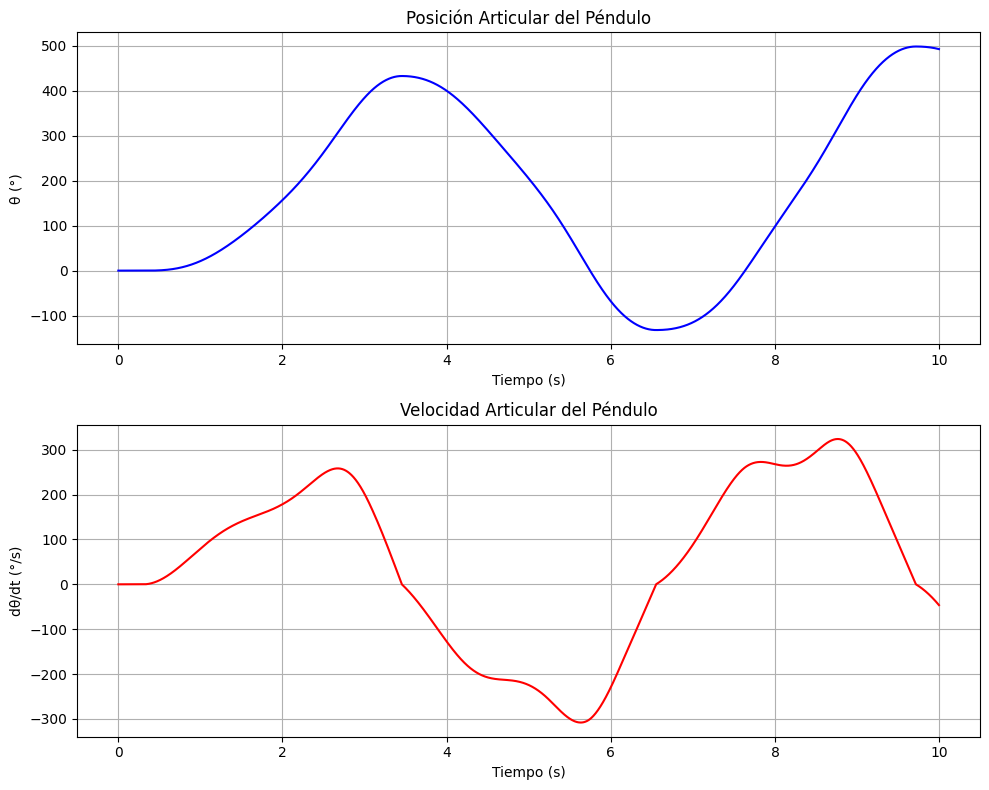

In [ ]:
ti = 0.0
tf = 10.0
h = 0.0025
ts = np.arange(ti, tf, h)

#2 CONDICIONES INICIALES
q0 = 0.0
qp0 = 0.0
x0 = [q0, qp0]

# 3 RESOLUCIÓN
sol = solve_ivp(f, [ti, tf], x0, t_eval=ts)

t = sol.t
posicion = sol.y[0]
velocidad = sol.y[1]

# 4 PROCEDIMIENTO Y GRÁFICAS
posicion_grados = np.rad2deg(posicion)
velocidad_grados = np.rad2deg(velocidad)

# FIGURA Y EJES
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# GRÁFICA DE POSICIÓN
ax1.plot(t, posicion_grados, 'b-', label='Posición (q)')
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('θ (°)')
ax1.set_title('Posición Articular del Péndulo')
ax1.grid(True)

# GRÁFICA DE VELOCIDAD
ax2.plot(t, velocidad_grados, 'r-', label='Velocidad (qp)')
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('dθ/dt (°/s)')
ax2.set_title('Velocidad Articular del Péndulo')
ax2.grid(True)

# AJUSTAR EL LAYOUT
plt.tight_layout()
plt.show()